선형 회귀

In [1]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [2]:
from sklearn.model_selection import train_test_split

#훈련 세트와 테스트 세트로 나누기
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

#2차원 배열로 바꾸기
train_input = train_input.reshape(-1,1)
test_input = test_input.reshape(-1,1)

from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

print(knr.predict([[50]])) #50cm 농어의 무게 예측

[1033.33333333]


최근접 이웃 산점도

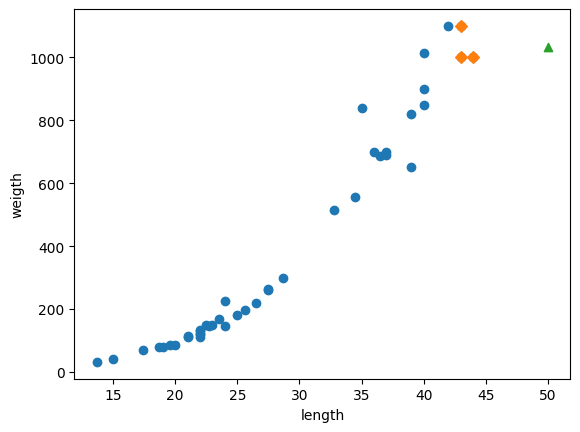

In [3]:
import matplotlib.pyplot as plot

distances, indexes = knr.kneighbors([[50]])

plot.scatter(train_input, train_target)
plot.scatter(train_input[indexes], train_target[indexes], marker='D')

plot.scatter(50, 1033, marker='^') #50cm 농어

plot.xlabel('length')
plot.ylabel('weigth')
plot.show()

샘플이 훈련 세트의 범위를 벗어나 가장 가까운 샘플인 1033으로 예측

k 최근접 이웃의 단점

이를 선형 회귀를 통해 극복

In [4]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

print(lr.predict([[50]]))

# coef - 기울기, intercept - y절편
print(lr.coef_, lr.intercept_) 

[1241.83860323]
[39.01714496] -709.0186449535474


산점도와 1차방정식 그래프를 한번에 그리기

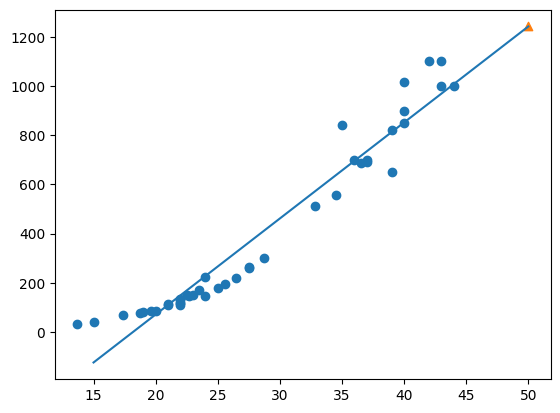

In [5]:
plot.scatter(train_input, train_target)

plot.plot([15, 50], [15*lr.coef_ + lr.intercept_, 50*lr.coef_ + lr.intercept_])

plot.scatter(50, 1241.8, marker='^')
plot.show()

결정계수 점수

In [6]:
print(lr.score(train_input, train_target))

print(lr.score(test_input, test_target))

0.9398463339976041
0.824750312331356


15cm 이하는 무게가 음수로 내려가기 때문에 다항 회귀 사용

In [7]:
train_poly = np.column_stack((train_input**2, train_input)) #길이의 제곱의 배열과 길이의 배열을 합침
test_poly = np.column_stack((test_input**2, test_input))

lr.fit(train_poly, train_target)

print(lr.predict([[50**2, 50]]))

print(lr.coef_, lr.intercept_)

[1573.98423528]
[  1.01433211 -21.55792498] 116.0502107827827


- 1.014 - 2차 계수
- -21.557 - 1차 계수
- 116.05 - 절편

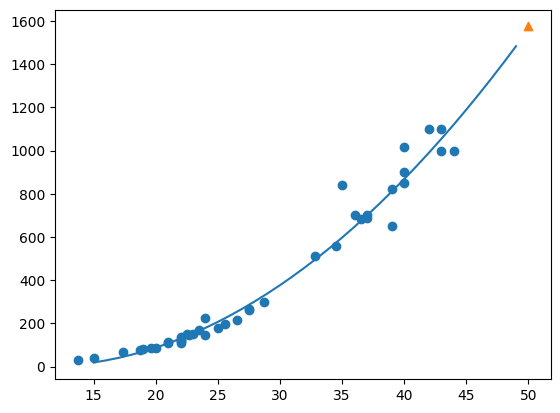

0.9706807451768623
0.9775935108325122


In [8]:
#실제로 2차방정식을 그리지 못하므로 각각의 점에서 직선을 그림
point = np.arange(15,50)

plot.scatter(train_input, train_target)

plot.plot(point, 1.01*point**2 - 21.6*point + 116.05) #각 정수마다 직선을 그려 2차방정식 형태로 만듦

plot.scatter([50],[1574],marker='^')
plot.show()

print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))